# PERSUADE 2.0 Corpus — Summary Statistics for AI-Driven Age Prediction

This notebook provides summary statistics for the [PERSUADE 2.0 corpus](https://github.com/scrosseye/persuade_corpus_2.0) (Crossley et al., 2024), with a focus on evaluating its suitability for **AI-driven age prediction based on linguistic patterns in minors' writing**.

**Reference:** Crossley, S. A., Baffour, P., Tian, Y., Franklin, A., Benner, M., & Boser, U. (2024). A large-scale corpus for assessing written argumentation: PERSUADE 2.0. *Assessing Writing*, 61. [doi:10.1016/j.asw.2024.100838](https://doi.org/10.1016/j.asw.2024.100838)

## Key Findings

1. **Prompt–grade confounding is severe:** 12 of 14 prompts are assigned to a single grade level, meaning a naive model could learn topic vocabulary rather than developmental linguistic markers.
2. **Demographic shifts across grades** (especially ELL status and race/ethnicity) create additional confounds that must be addressed.
3. **Class imbalance:** Grade 8 and 10 dominate; Grade 7 is entirely absent; Grade 12 has only 243 essays.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load and Deduplicate to Essay Level

The CSV is structured at the **discourse-element level** (multiple rows per essay). We deduplicate to get one row per essay.

In [2]:
# Load the data — adjust path as needed
raw = pd.read_csv('persuade_corpus_2.0_train.csv')
print(f'Raw rows (discourse-element level): {len(raw):,}')

# Deduplicate to essay level
essay_cols = [
    'essay_id_comp', 'full_text', 'holistic_essay_score', 'provider', 'task',
    'source_text', 'prompt_name', 'assignment', 'gender', 'grade_level',
    'ell_status', 'race_ethnicity', 'economically_disadvantaged',
    'student_disability_status', 'essay_word_count'
]
df = raw.drop_duplicates(subset='essay_id_comp')[essay_cols].copy()
df = df.set_index('essay_id_comp')
print(f'Unique essays: {len(df):,}')
print(f'Columns: {list(df.columns)}')

Raw rows (discourse-element level): 173,266
Unique essays: 15,594
Columns: ['full_text', 'holistic_essay_score', 'provider', 'task', 'source_text', 'prompt_name', 'assignment', 'gender', 'grade_level', 'ell_status', 'race_ethnicity', 'economically_disadvantaged', 'student_disability_status', 'essay_word_count']


## 2. Missingness

For an age-prediction project, understanding which columns have missing data — and whether missingness is correlated with grade level — is essential.

In [3]:
key_cols = [
    'grade_level', 'gender', 'race_ethnicity', 'ell_status',
    'economically_disadvantaged', 'student_disability_status',
    'holistic_essay_score', 'task', 'prompt_name', 'essay_word_count'
]

missing = pd.DataFrame({
    'Missing Count': df[key_cols].isna().sum(),
    'Missing %': (df[key_cols].isna().mean() * 100).round(1)
})
display(missing)

,Missing Count,Missing %
grade_level,701,4.5
gender,0,0.0
race_ethnicity,0,0.0
ell_status,722,4.6
economically_disadvantaged,3534,22.7
student_disability_status,3502,22.5
holistic_essay_score,0,0.0
task,0,0.0
prompt_name,0,0.0
essay_word_count,0,0.0


## 3. Target Variable: Grade Level Distribution

`grade_level` is the age proxy. Note the **absence of Grade 7** and the severe imbalance.

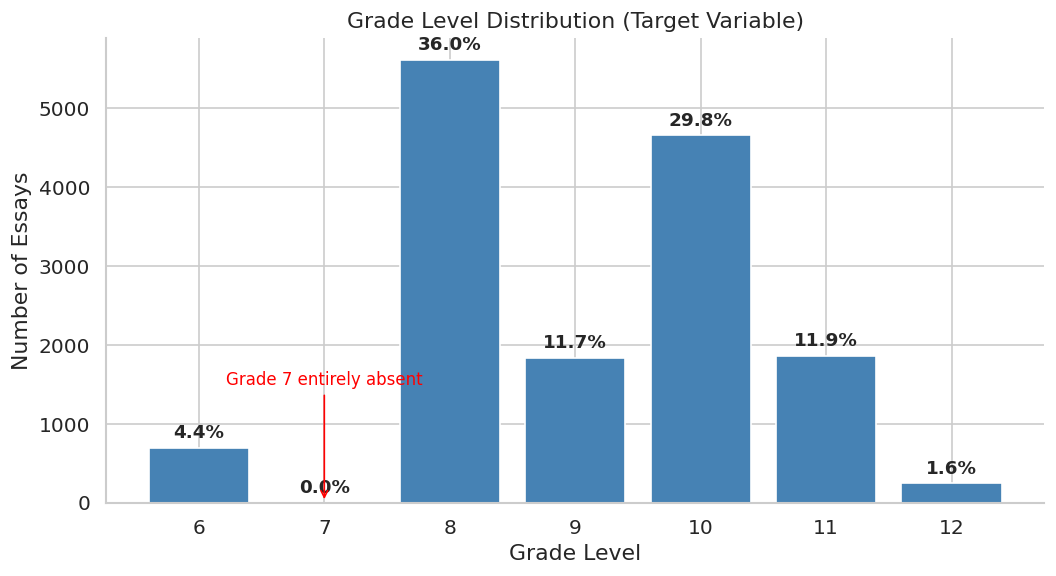

Missing grade level: 701 essays (4.5%)


In [4]:
grade_order = [6, 7, 8, 9, 10, 11, 12]

grade_counts = df['grade_level'].value_counts().reindex(grade_order, fill_value=0)
grade_pct = (grade_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(grade_counts.index.astype(str), grade_counts.values, color='steelblue', edgecolor='white')
for bar, pct in zip(bars, grade_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Grade Level')
ax.set_ylabel('Number of Essays')
ax.set_title('Grade Level Distribution (Target Variable)')
ax.annotate('Grade 7 entirely absent', xy=('7', 0), xytext=('7', 1500),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red', ha='center')
sns.despine()
plt.tight_layout()
plt.show()

n_missing = df['grade_level'].isna().sum()
print(f'Missing grade level: {n_missing} essays ({100*n_missing/len(df):.1f}%)')

## 4. ⚠️ Critical Issue: Prompt–Grade Confounding

**12 of 14 prompts are assigned to exactly one grade level.** A model could achieve high accuracy by learning topic vocabulary (e.g., "Venus" → Grade 10) rather than genuine developmental linguistic patterns. This is the most serious threat to validity.

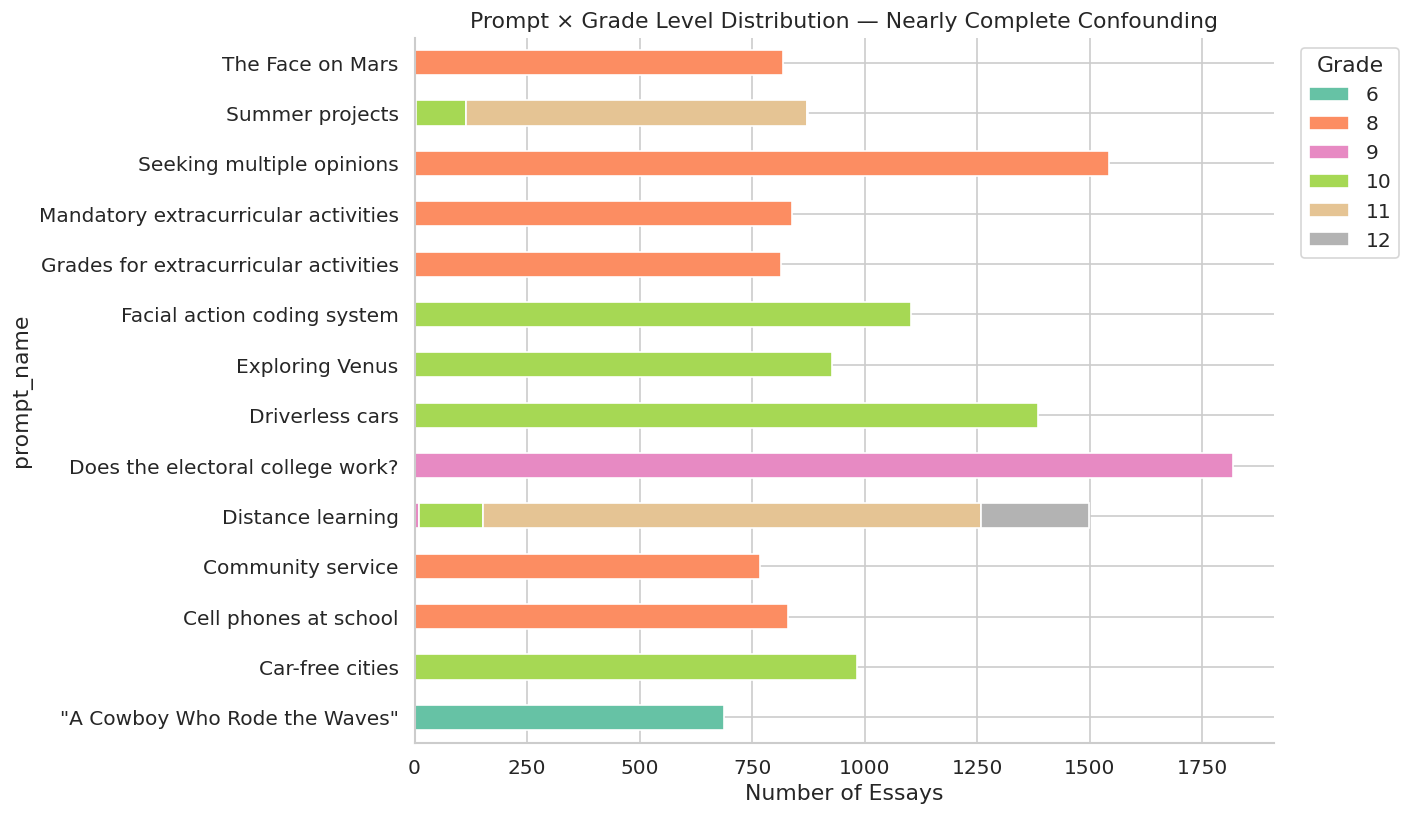

Single-grade prompts: 12/14
Multi-grade prompts:  2/14

grade_level                                    type
prompt_name                                        
"A Cowboy Who Rode the Waves"          SINGLE-GRADE
Car-free cities                        SINGLE-GRADE
Cell phones at school                  SINGLE-GRADE
Community service                      SINGLE-GRADE
Distance learning                       MULTI-GRADE
Does the electoral college work?       SINGLE-GRADE
Driverless cars                        SINGLE-GRADE
Exploring Venus                        SINGLE-GRADE
Facial action coding system            SINGLE-GRADE
Grades for extracurricular activities  SINGLE-GRADE
Mandatory extracurricular activities   SINGLE-GRADE
Seeking multiple opinions              SINGLE-GRADE
Summer projects                         MULTI-GRADE
The Face on Mars                       SINGLE-GRADE


In [5]:
# Build prompt × grade cross-tab
df_graded = df.dropna(subset=['grade_level']).copy()
df_graded['grade_level'] = df_graded['grade_level'].astype(int)

prompt_grade = pd.crosstab(df_graded['prompt_name'], df_graded['grade_level'])
prompt_grade = prompt_grade.reindex(columns=[6, 8, 9, 10, 11, 12], fill_value=0)

# Classify prompts
prompt_grade['n_grades'] = (prompt_grade > 0).sum(axis=1)
prompt_grade['type'] = prompt_grade['n_grades'].map(lambda x: 'SINGLE-GRADE' if x == 1 else 'MULTI-GRADE')

fig, ax = plt.subplots(figsize=(12, 7))
plot_data = prompt_grade.drop(columns=['n_grades', 'type'])
plot_data.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Number of Essays')
ax.set_title('Prompt × Grade Level Distribution — Nearly Complete Confounding')
ax.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# Summary table
n_single = (prompt_grade['type'] == 'SINGLE-GRADE').sum()
n_multi = (prompt_grade['type'] == 'MULTI-GRADE').sum()
print(f'Single-grade prompts: {n_single}/{n_single+n_multi}')
print(f'Multi-grade prompts:  {n_multi}/{n_single+n_multi}')
print()
print(prompt_grade[['type']].to_string())

## 5. Essay Word Count

Word count is a basic but informative feature — and it does vary by grade level, though this is partially confounded with prompt/task type.

,Statistic,Value
0,N,15594
1,Mean,429.6
2,Median,387.0
3,Std Dev,281.8
4,Min,146
5,25th pctl,279
6,75th pctl,523
7,Max,14714
8,Essays < 200 words,1244


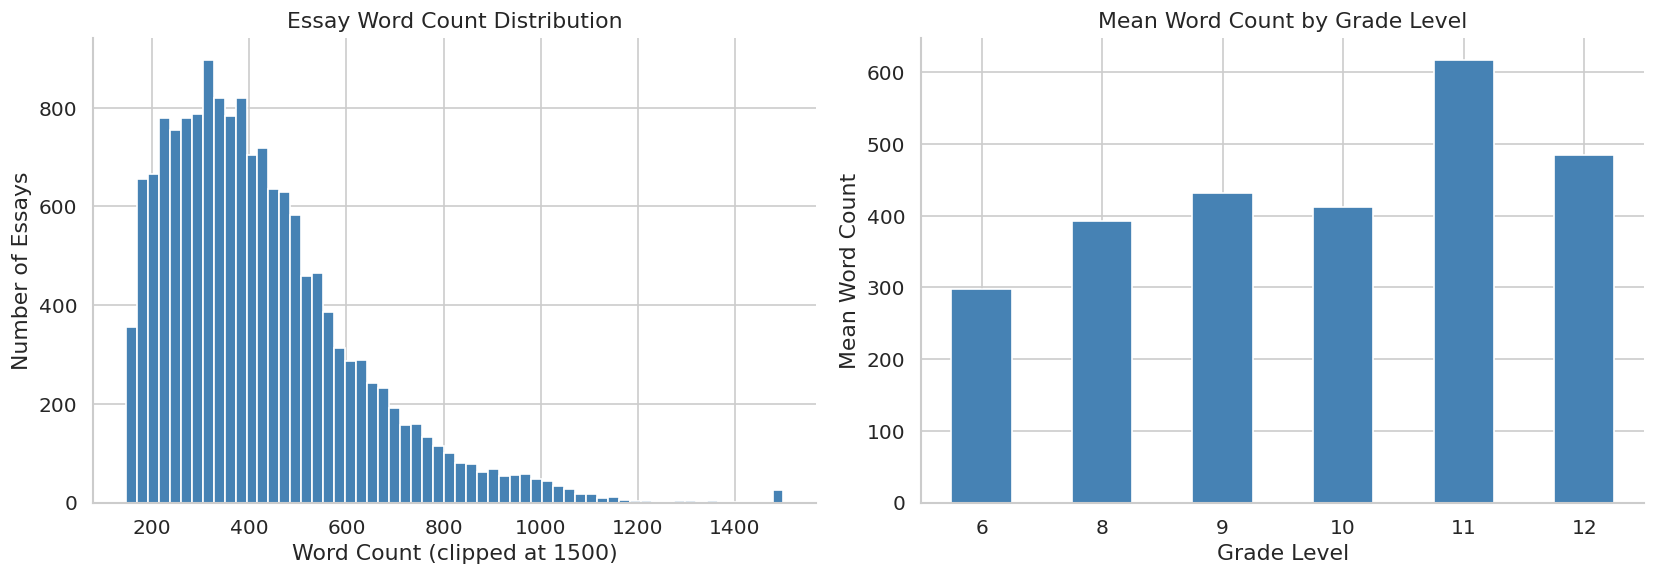

Word count by grade:


,mean,median,std,count
grade_level,,,,
6,297.4,275.0,126.7,688
8,393.0,349.5,219.5,5614
9,432.0,390.0,308.1,1831
10,411.5,376.0,353.7,4654
11,617.5,596.0,203.3,1863
12,484.9,449.0,234.4,243


In [6]:
# Overall distribution
wc = df['essay_word_count']
stats = pd.DataFrame({
    'Statistic': ['N', 'Mean', 'Median', 'Std Dev', 'Min', '25th pctl', '75th pctl', 'Max', 'Essays < 200 words'],
    'Value': [len(wc), f'{wc.mean():.1f}', f'{wc.median():.1f}', f'{wc.std():.1f}',
              wc.min(), f'{wc.quantile(0.25):.0f}', f'{wc.quantile(0.75):.0f}',
              wc.max(), (wc < 200).sum()]
})
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (clipped for readability)
axes[0].hist(wc.clip(upper=1500), bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Word Count (clipped at 1500)')
axes[0].set_ylabel('Number of Essays')
axes[0].set_title('Essay Word Count Distribution')

# By grade
grade_wc = df_graded.groupby('grade_level')['essay_word_count'].agg(['mean', 'median', 'std', 'count'])
grade_wc[['mean']].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', legend=False)
axes[1].set_xlabel('Grade Level')
axes[1].set_ylabel('Mean Word Count')
axes[1].set_title('Mean Word Count by Grade Level')
axes[1].tick_params(axis='x', rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

print('Word count by grade:')
display(grade_wc.round(1))

## 6. Holistic Essay Score

Scored on a 1–6 scale. Score correlates with grade level but is not monotonic — Grade 11 has the highest mean score (4.65) while Grade 12 drops back to 3.34, likely due to the very different demographic composition of Grade 12.

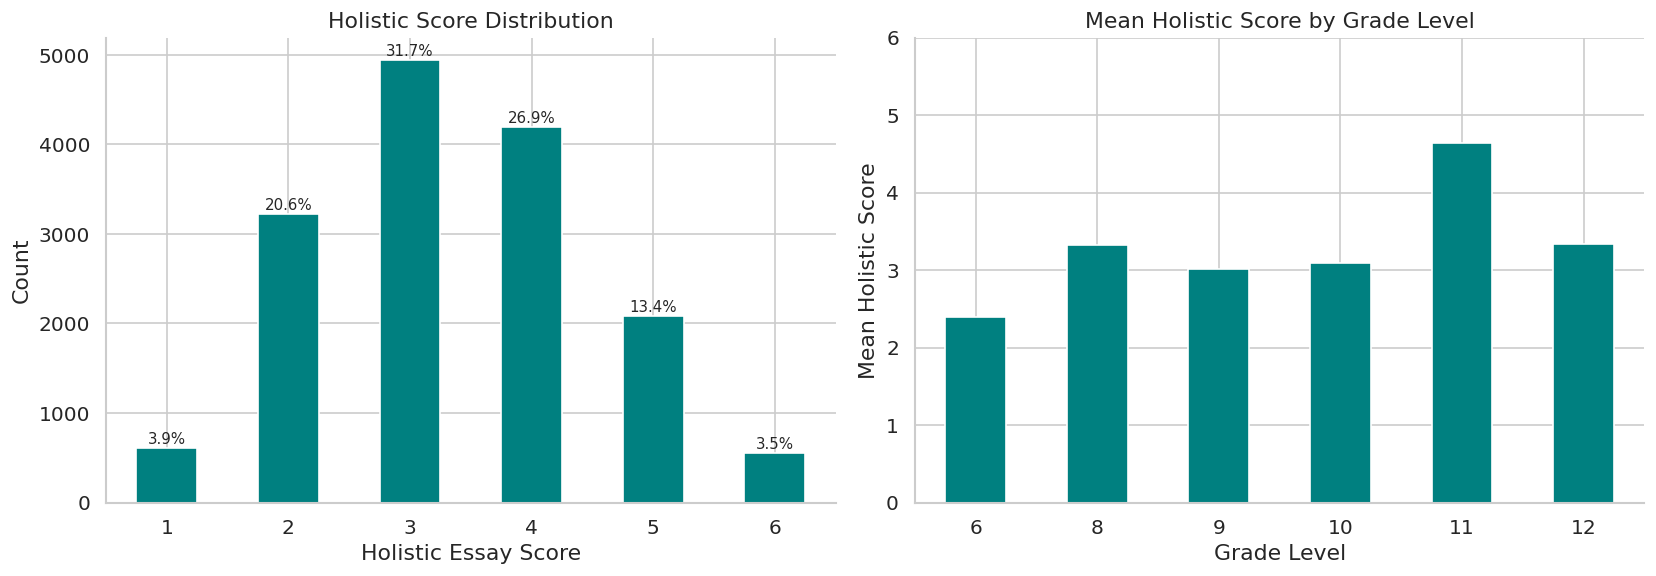

,mean,median
grade_level,,
6,2.39,2.0
8,3.32,3.0
9,3.02,3.0
10,3.09,3.0
11,4.65,5.0
12,3.34,3.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
score_counts = df['holistic_essay_score'].value_counts().sort_index()
score_counts.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_xlabel('Holistic Essay Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Holistic Score Distribution')
axes[0].tick_params(axis='x', rotation=0)
for i, (idx, val) in enumerate(score_counts.items()):
    axes[0].text(i, val + 50, f'{100*val/len(df):.1f}%', ha='center', fontsize=9)

# Mean score by grade
grade_score = df_graded.groupby('grade_level')['holistic_essay_score'].agg(['mean', 'median'])
grade_score['mean'].plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_xlabel('Grade Level')
axes[1].set_ylabel('Mean Holistic Score')
axes[1].set_title('Mean Holistic Score by Grade Level')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 6)

sns.despine()
plt.tight_layout()
plt.show()

display(grade_score.round(2))

## 7. Demographic Distributions — Fairness Audit

These columns are critical for assessing whether a model is picking up genuine developmental signals vs. demographic proxies.

### 7a. Gender

In [8]:
print('Gender distribution:')
print(df['gender'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))
print('\nGender × Grade Level:')
display(pd.crosstab(df_graded['grade_level'], df_graded['gender'], normalize='index').round(3) * 100)

Gender distribution:
        count   pct
gender             
F        7882  50.5
M        7712  49.5

Gender × Grade Level:


gender,F,M
grade_level,,
6,53.9,46.1
8,52.0,48.0
9,50.5,49.5
10,50.6,49.4
11,49.4,50.6
12,49.4,50.6


### 7b. Race/Ethnicity

**Key concern:** The racial composition shifts dramatically across grades. Grade 12 is 67% Hispanic and only 5% White, while Grade 6 is 56% White. A model could conflate dialect or cultural linguistic features with age.

Overall race/ethnicity distribution:
                                count   pct
race_ethnicity                             
White                            7012  45.0
Hispanic/Latino                  3869  24.8
Black/African American           2975  19.1
Asian/Pacific Islander           1072   6.9
Two or more races/Other           598   3.8
American Indian/Alaskan Native     68   0.4


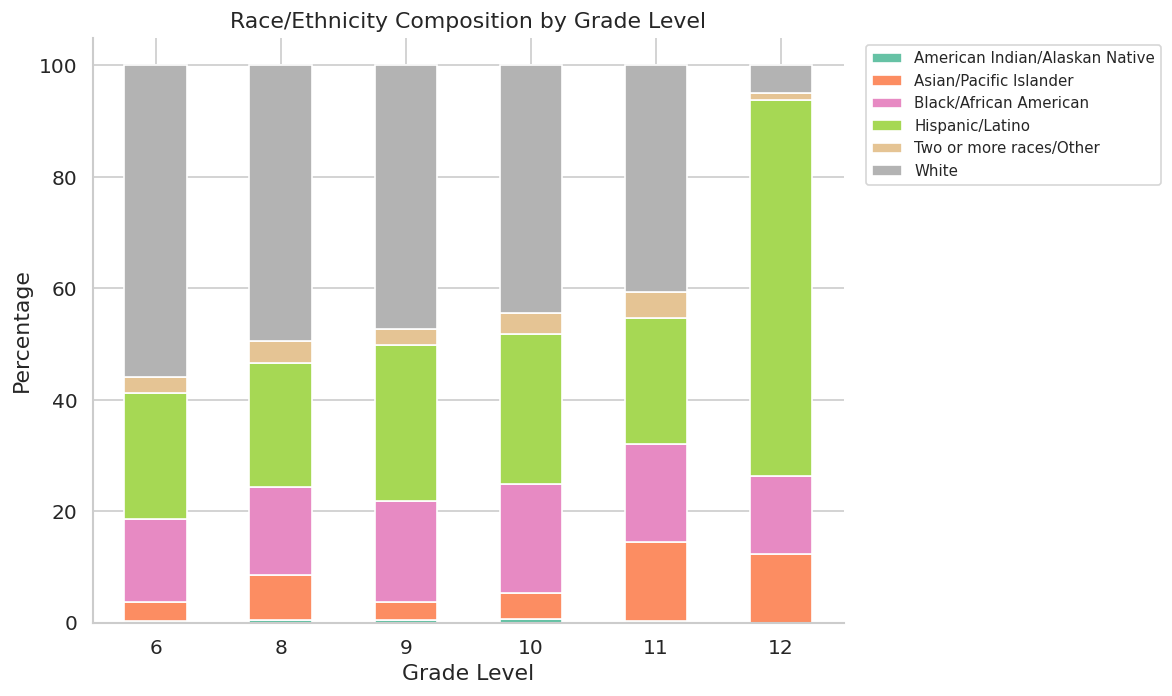

In [9]:
# Overall
print('Overall race/ethnicity distribution:')
race_dist = df['race_ethnicity'].value_counts()
print(race_dist.to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))

# By grade — stacked bar
race_by_grade = pd.crosstab(df_graded['grade_level'], df_graded['race_ethnicity'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
race_by_grade.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Grade Level')
ax.set_ylabel('Percentage')
ax.set_title('Race/Ethnicity Composition by Grade Level')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, 105)
sns.despine()
plt.tight_layout()
plt.show()

### 7c. ELL Status

**Extreme confound:** 93.8% of Grade 12 students are English Language Learners, compared to just 2.3% in Grade 6. A model could easily conflate L1 interference patterns with age-related writing features.

Overall ELL status:
ell_status
No     13467
Yes     1330
NaN      722
          75
Name: count, dtype: int64



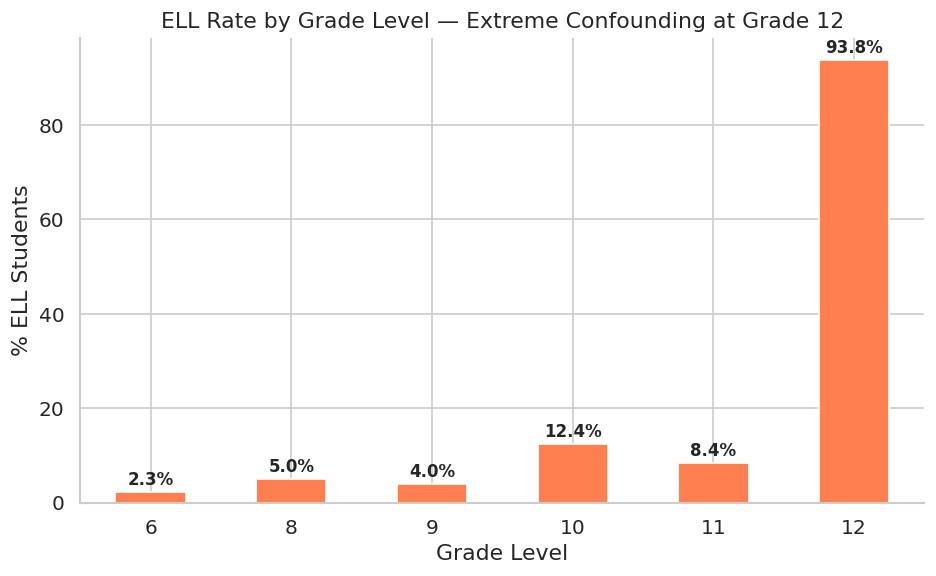

In [10]:
print('Overall ELL status:')
print(df['ell_status'].value_counts(dropna=False))
print()

# ELL rate by grade
ell_by_grade = df_graded.dropna(subset=['ell_status']).groupby('grade_level')['ell_status'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
ell_by_grade.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('Grade Level')
ax.set_ylabel('% ELL Students')
ax.set_title('ELL Rate by Grade Level — Extreme Confounding at Grade 12')
ax.tick_params(axis='x', rotation=0)
for i, (idx, val) in enumerate(ell_by_grade.items()):
    ax.text(i, val + 1.5, f'{val}%', ha='center', fontsize=10, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

### 7d. Economic Disadvantage & Disability Status

Both have ~22.5% missing data, limiting their use for stratified analysis.

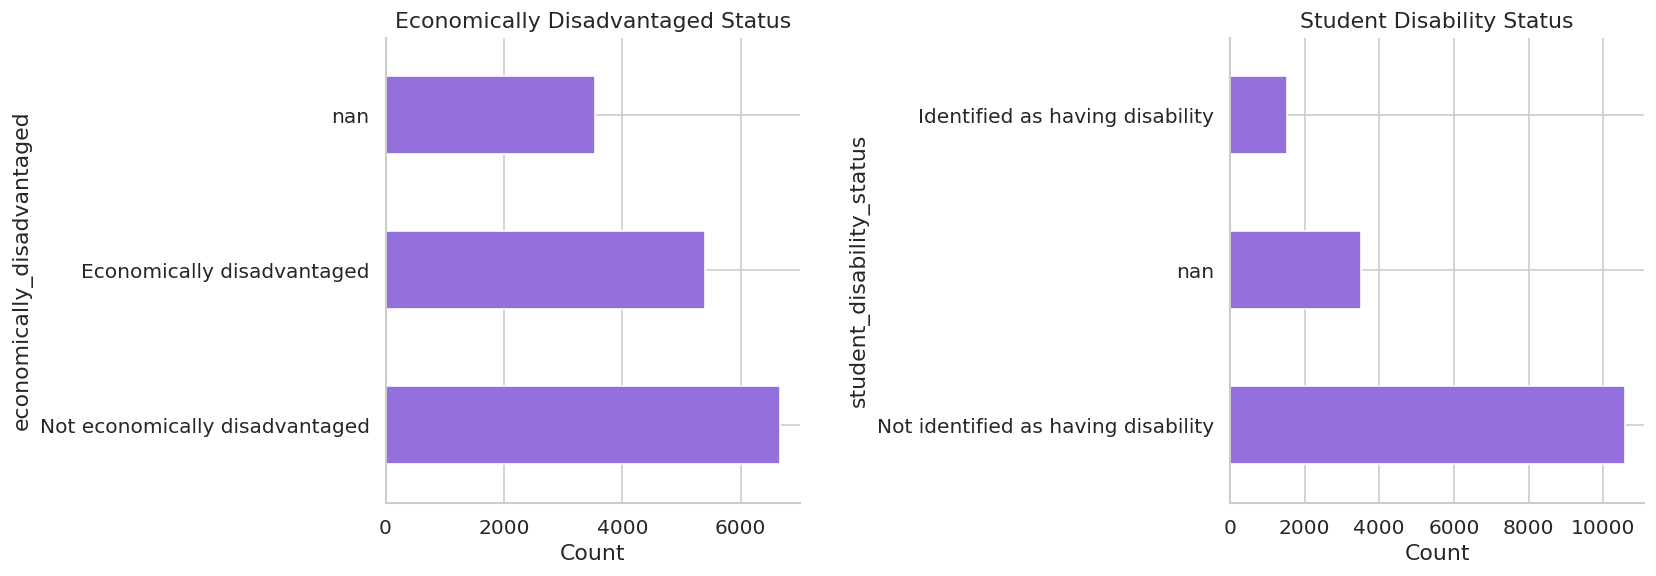

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Economic disadvantage
econ = df['economically_disadvantaged'].value_counts(dropna=False)
econ.plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Economically Disadvantaged Status')
axes[0].set_xlabel('Count')

# Disability
dis = df['student_disability_status'].value_counts(dropna=False)
dis.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Student Disability Status')
axes[1].set_xlabel('Count')

sns.despine()
plt.tight_layout()
plt.show()

## 8. Task Type

In [12]:
print('Task type distribution:')
print(df['task'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))
print()
print('Task type × Grade Level:')
display(pd.crosstab(df_graded['grade_level'], df_graded['task']))

Task type distribution:
                count   pct
task                       
Independent      7869  50.5
Text dependent   7725  49.5

Task type × Grade Level:


task,Independent,Text dependent
grade_level,,
6,0,688
8,4795,819
9,13,1818
10,254,4400
11,1863,0
12,243,0


## 9. Summary & Recommendations

| Concern | Severity | Detail |
|---------|----------|--------|
| **Prompt–grade confounding** | 🔴 Critical | 12/14 prompts assigned to a single grade; model may learn topic, not age |
| **ELL–grade confounding** | 🔴 Critical | 93.8% ELL at Grade 12 vs. 2.3% at Grade 6 |
| **Race–grade confounding** | 🟠 High | Grade 12 is 67% Hispanic; Grade 6 is 56% White |
| **Class imbalance** | 🟠 High | Grade 7 absent; Grade 12 has only 243 essays |
| **Missing demographics** | 🟡 Moderate | ~22.5% missing for economic & disability status |
| **Grade level missingness** | 🟡 Moderate | 4.5% missing |

### Recommended mitigations

1. **Topic-agnostic features:** Use syntactic complexity, vocabulary diversity, error rates, sentence structure — not content words.
2. **Cross-prompt validation:** Hold out the two multi-grade prompts ("Distance learning" and "Summer projects") as an integrity check.
3. **Content-word ablation:** Mask or remove nouns/named entities and verify model performance holds.
4. **Stratified fairness evaluation:** Report performance separately by race/ethnicity and ELL status.
5. **Consider excluding Grade 12:** Its extreme ELL composition (93.8%) makes it non-comparable to other grades.